## Challenge

##### Hello campers! Here's a challenge for the PythonML Camp. In the data folder, you can find the file students_pass_fail.csv. Your task is to build a machine learning model that predicts whether a student will pass or fail based on their grade and absences in the school year.
    
#### Description of the csv file: 
    grade,absences,label
    95,1,Pass
    "grade" ranges from 0-100 and represents the numerical GPA of the student.
    "absences" ranges from 0-20 and represents the number of days the student was absent in the schoo year.
    "label" represents pass ("Pass") or fail ("Fail") of the student.
    
#### You may use the following machine learning models to build your model:
    - Logistic Regression
    - KNN
    - Decision Tree
    - Random Forest
    - SVM
        
#### Have fun!

Hint: If using KNN, you may run into an error with this line of code: *point_color = cmap(predicted_class)* because your prediction returns "pass" or "fail", which is not a numerical value that the cmap function can use. Use this instead: *point_color = cmap(pd.factorize(predicted_class)[0])*

    

In [7]:
import pandas as pd

In [23]:
df = pd.read_csv('data/students_pass_fail.csv')
X = df[['grade', 'absences']]
y = pd.factorize(df["label"])[0]
df.head()

,grade,absences,label
0,95,1,Pass
1,92,0,Pass
2,90,2,Pass
3,88,1,Pass
4,86,3,Pass


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

[]

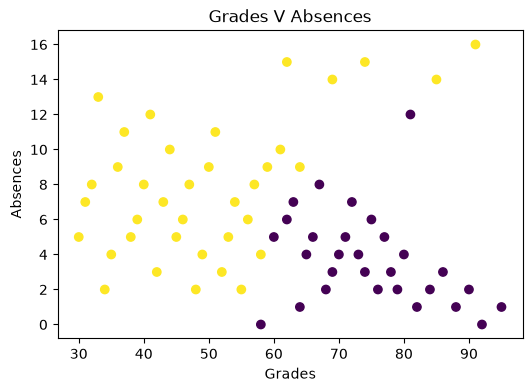

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize = (6, 4))
plt.scatter(X["grade"], X["absences"], cmap = 'viridis', c = y)
plt.xlabel('Grades')
plt.ylabel('Absences')
plt.title('Grades V Absences')
plt.plot()

In [27]:
from sklearn.svm import SVC
model = SVC(kernel = 'rbf')
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

[]

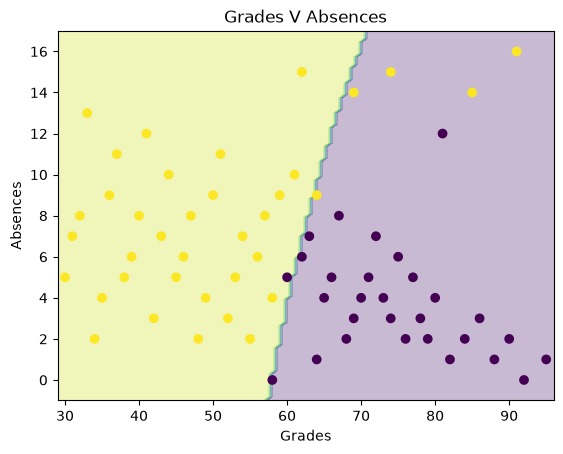

In [31]:
from sklearn.inspection import DecisionBoundaryDisplay
disp = DecisionBoundaryDisplay.from_estimator(
    model, X, response_method = 'predict', alpha = 0.3,
)
plt.scatter(X['grade'], X['absences'], cmap = 'viridis', c = y)
plt.xlabel('Grades')
plt.ylabel('Absences')
plt.title('Grades V Absences')
plt.plot()

In [34]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_train, y_pred_train))

1.0
0.8846153846153846
